# **Import**
Import library & download resource dari NLTK

In [1]:
# Library essential
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import requests
from io import StringIO

# Library pre/processing kata (dalam bentuk string)
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

# Library visualisasi kata
from wordcloud import WordCloud

# Library Ekstraksi Fitur
!pip install gensim
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Library ML Standar
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# Library DL RNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from sklearn.preprocessing import LabelEncoder

# Library evaluasi
from sklearn.metrics import accuracy_score, precision_score

# Tambahan
pd.options.mode.chained_assignment = None

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# **Dataset Loading**


Load dataset hasil scraping

In [2]:
df = pd.read_csv('ulasan_CSR2.csv')
jumlah_data, jumlah_kolom = df.shape
print(df.shape)

(130500, 11)


In [3]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7d2106bf-5a5d-4335-a742-8ed985f47ba8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Awsome game play and graphics. A ton of differ...,2,178,5.9.0,2025-09-20 08:47:38,"Hi Smokey, sorry about your experience and we ...",2025-09-21 20:04:30,5.9.0
1,8bc863d9-878b-4a90-8efa-a25beaccedea,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,originally downloaded because of a promotion f...,5,2437,5.6.1,2025-03-22 05:53:28,NaN,NaN,5.6.1
2,1b86c521-07a7-4303-99f4-3e317d3d0f14,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Really really enjoy the game but its getting h...,4,15,6.0.1,2025-10-03 00:18:09,NaN,NaN,6.0.1
3,696c23f9-969c-4b99-bd33-0e85c2cf80c6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"any multilayer race, and I'm put up against so...",1,23,6.0.1,2025-10-03 18:37:21,"Hi John, we're sorry to hear that you're not e...",2025-10-04 21:23:53,6.0.1
4,bdc22ec9-3cff-4eeb-89ea-8ad7e5264546,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"ok, im not sure why my review was removed, but...",4,1,6.0.1,2025-10-03 13:26:12,Hi Jonathan. We appreciate your detailed feedb...,2025-10-04 21:44:42,6.0.1


Drop kolom tidak relevan (agar lebih cepat)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130500 entries, 0 to 130499
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              130500 non-null  object
 1   userName              130500 non-null  object
 2   userImage             130500 non-null  object
 3   content               130500 non-null  object
 4   score                 130500 non-null  int64 
 5   thumbsUpCount         130500 non-null  int64 
 6   reviewCreatedVersion  115497 non-null  object
 7   at                    130500 non-null  object
 8   replyContent          49405 non-null   object
 9   repliedAt             49405 non-null   object
 10  appVersion            115497 non-null  object
dtypes: int64(2), object(9)
memory usage: 11.0+ MB


In [5]:
df = df.drop(columns=['reviewId',
                      'userName',
                      'userImage',
                      'score',
                      'thumbsUpCount',
                      'reviewCreatedVersion',
                      'at',
                      'replyContent',
                      'repliedAt',
                      'appVersion'])

Drop data null & duplikat

In [6]:
df.info()
# Sebelum drop null & duplicate

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130500 entries, 0 to 130499
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   content  130500 non-null  object
dtypes: object(1)
memory usage: 1019.7+ KB


In [7]:
clean_df = df.dropna()
clean_df = clean_df.drop_duplicates()

print(clean_df.shape)
# Ukuran dataframe lebih kecil

(126914, 1)


In [8]:
clean_df.info()
# Setelah drop null & duplicate

<class 'pandas.core.frame.DataFrame'>
Index: 126914 entries, 0 to 130499
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   content  126914 non-null  object
dtypes: object(1)
memory usage: 1.9+ MB


#**Data Preprocessing**

Method pembersihan data

In [9]:
# 1. Case Folding
def CaseFolding(text):
    text = text.lower()
    return text

# 2. Removal Special Characters
def RemoveSpecialCharacter(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers
    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

# 3. Stopword Removal
def RemoveStopwords(text):
    listStopwords = set(stopwords.words('english'))
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

# 4. Tokenizing
def TokenizeText(text):
    text = word_tokenize(text)
    return text

# 5. Lemmatization
def LemmatizeText(text):
    lemmatizer = WordNetLemmatizer()

    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word.lower()) for word in words]
    lemmatized_text = ' '.join(lemmatized_words)
    return lemmatized_text


# Tambahan dari Colab contoh
def ToSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

# Menggunakan dictionary slang bahasa Inggris dari GitHub
# Credits: https://github.com/sifei/Dictionary-for-Sentiment-Analysis
slangwords = dict()
response = requests.get('https://raw.githubusercontent.com/sifei/Dictionary-for-Sentiment-Analysis/refs/heads/master/slang/acrynom.csv')

if response.status_code == 200:
  reader = csv.reader(StringIO(response.text), delimiter=',')
  for rows in reader:
    slangwords[rows[0]] = rows[1]
else:
    print("Error mengambil dictionary slangword")

def FixSlangwords(text):
  words = text.split()
  fixed_words = []

  for word in words:
    if word.lower() in slangwords:
      fixed_words.append(slangwords[word.lower()])
    else:
      fixed_words.append(word)
  fixed_text = ' '.join(fixed_words)
  return fixed_text

# Credits: sebagian besar blok kode ini dimodifikasi dari versi asli Google Colab contoh penerapan NLP
# https://colab.research.google.com/drive/173RsZ-l3SAd2VZwKisXisxYbKKsp28Qd

Dataframe sebelum preprocessing text:

In [10]:
clean_df

,content
0,Awsome game play and graphics. A ton of differ...
1,originally downloaded because of a promotion f...
2,Really really enjoy the game but its getting h...
3,"any multilayer race, and I'm put up against so..."
4,"ok, im not sure why my review was removed, but..."
...,...
130495,"its, so fun and eterrtain"
130496,I love the 🎮 because I got an adventodor l.p. ...
130497,Good casual racing game
130498,Awesome game and addictive


In [11]:
# Menjalankan preprocessing text (dari method sebelumnya) ke semua data review.
# Hasil setiap method disimpan di kolom tersendiri

clean_df['text_casefoldingText'] = clean_df['content'].apply(CaseFolding)
clean_df['text_clean'] = clean_df['text_casefoldingText'].apply(RemoveSpecialCharacter)
clean_df['text_slangwords'] = clean_df['text_clean'].apply(FixSlangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(TokenizeText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(RemoveStopwords)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(ToSentence)

In [12]:
clean_df

,content,text_casefoldingText,text_clean,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,Awsome game play and graphics. A ton of differ...,awsome game play and graphics. a ton of differ...,awsome game play and graphics a ton of differe...,awesome game play and graphics a ton of differ...,"[awesome, game, play, and, graphics, a, ton, o...","[awesome, game, play, graphics, ton, different...",awesome game play graphics ton different cars ...
1,originally downloaded because of a promotion f...,originally downloaded because of a promotion f...,originally downloaded because of a promotion f...,originally downloaded because of a promotion f...,"[originally, downloaded, because, of, a, promo...","[originally, downloaded, promotion, another, g...",originally downloaded promotion another game e...
2,Really really enjoy the game but its getting h...,really really enjoy the game but its getting h...,really really enjoy the game but its getting h...,really really enjoy the game but its getting h...,"[really, really, enjoy, the, game, but, its, g...","[really, really, enjoy, game, getting, hard, p...",really really enjoy game getting hard play gam...
3,"any multilayer race, and I'm put up against so...","any multilayer race, and i'm put up against so...",any multilayer race and im put up against some...,any multilayer race and Instant Message put up...,"[any, multilayer, race, and, Instant, Message,...","[multilayer, race, Instant, Message, put, some...",multilayer race Instant Message put someone sp...
4,"ok, im not sure why my review was removed, but...","ok, im not sure why my review was removed, but...",ok im not sure why my review was removed but t...,okay Instant Message not sure why my review wa...,"[okay, Instant, Message, not, sure, why, my, r...","[okay, Instant, Message, sure, review, removed...",okay Instant Message sure review removed fun g...
...,...,...,...,...,...,...,...
130495,"its, so fun and eterrtain","its, so fun and eterrtain",its so fun and eterrtain,its so fun and eterrtain,"[its, so, fun, and, eterrtain]","[fun, eterrtain]",fun eterrtain
130496,I love the 🎮 because I got an adventodor l.p. ...,i love the 🎮 because i got an adventodor l.p. ...,i love the because i got an adventodor lp fo...,i love the because i got an adventodor lp for ...,"[i, love, the, because, i, got, an, adventodor...","[love, got, adventodor, lp, free, best, car]",love got adventodor lp free best car
130497,Good casual racing game,good casual racing game,good casual racing game,good casual racing game,"[good, casual, racing, game]","[good, casual, racing, game]",good casual racing game
130498,Awesome game and addictive,awesome game and addictive,awesome game and addictive,awesome game and addictive,"[awesome, game, and, addictive]","[awesome, game, addictive]",awesome game addictive


Pelabelan

In [13]:
# Pelabelan menggunakan libary VADER milik NLTK yang sudah memiliki list lexicon
# positif dan negatif, serta skor untuk setiap lexicon tersebut
vader = SentimentIntensityAnalyzer()

lexicon_positive = dict()
lexicon_negative = dict()

# Lexicon disimpan berdasarkan ploaritasnya
# di dictionary (menyesuaikan contoh)
for kata, skor in vader.lexicon.items():
  if skor >= 0.0:
    lexicon_positive[kata] = skor
  elif skor < 0.0:
    lexicon_negative[kata] = skor

In [14]:
# Method untuk menentukan polaritas review dengan menghitung skor setiap kata
def AnalisaSentimen(text):
  score = 0
  for word in text:
    if (word in lexicon_positive):
      score = score + lexicon_positive[word]
    elif (word in lexicon_negative):
      score = score + lexicon_negative[word]

  polarity=''
  if (score > 0):
    polarity = 'positive'
  elif (score < 0):
    polarity = 'negative'
  else:
    polarity = 'neutral'

  return score, polarity

In [15]:
# Method tadi digunakan untuk setiap review, dengan hasil kolom polarity_score & polarity
results = clean_df['text_stopword'].apply(AnalisaSentimen)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())
clean_df

polarity
positive    110483
negative     10711
neutral       5720
Name: count, dtype: int64


,content,text_casefoldingText,text_clean,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,Awsome game play and graphics. A ton of differ...,awsome game play and graphics. a ton of differ...,awsome game play and graphics a ton of differe...,awesome game play and graphics a ton of differ...,"[awesome, game, play, and, graphics, a, ton, o...","[awesome, game, play, graphics, ton, different...",awesome game play graphics ton different cars ...,0.9,positive
1,originally downloaded because of a promotion f...,originally downloaded because of a promotion f...,originally downloaded because of a promotion f...,originally downloaded because of a promotion f...,"[originally, downloaded, because, of, a, promo...","[originally, downloaded, promotion, another, g...",originally downloaded promotion another game e...,14.2,positive
2,Really really enjoy the game but its getting h...,really really enjoy the game but its getting h...,really really enjoy the game but its getting h...,really really enjoy the game but its getting h...,"[really, really, enjoy, the, game, but, its, g...","[really, really, enjoy, game, getting, hard, p...",really really enjoy game getting hard play gam...,0.7,positive
3,"any multilayer race, and I'm put up against so...","any multilayer race, and i'm put up against so...",any multilayer race and im put up against some...,any multilayer race and Instant Message put up...,"[any, multilayer, race, and, Instant, Message,...","[multilayer, race, Instant, Message, put, some...",multilayer race Instant Message put someone sp...,-1.3,negative
4,"ok, im not sure why my review was removed, but...","ok, im not sure why my review was removed, but...",ok im not sure why my review was removed but t...,okay Instant Message not sure why my review wa...,"[okay, Instant, Message, not, sure, why, my, r...","[okay, Instant, Message, sure, review, removed...",okay Instant Message sure review removed fun g...,12.3,positive
...,...,...,...,...,...,...,...,...,...
130495,"its, so fun and eterrtain","its, so fun and eterrtain",its so fun and eterrtain,its so fun and eterrtain,"[its, so, fun, and, eterrtain]","[fun, eterrtain]",fun eterrtain,2.3,positive
130496,I love the 🎮 because I got an adventodor l.p. ...,i love the 🎮 because i got an adventodor l.p. ...,i love the because i got an adventodor lp fo...,i love the because i got an adventodor lp for ...,"[i, love, the, because, i, got, an, adventodor...","[love, got, adventodor, lp, free, best, car]",love got adventodor lp free best car,8.7,positive
130497,Good casual racing game,good casual racing game,good casual racing game,good casual racing game,"[good, casual, racing, game]","[good, casual, racing, game]",good casual racing game,2.7,positive
130498,Awesome game and addictive,awesome game and addictive,awesome game and addictive,awesome game and addictive,"[awesome, game, and, addictive]","[awesome, game, addictive]",awesome game addictive,3.1,positive


Visualisasi

Pie chart

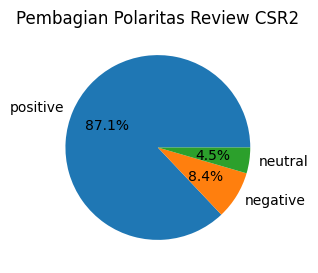

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 3))
sizes = [count for count in clean_df['polarity'].value_counts()]
labels = list(clean_df['polarity'].value_counts().index)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%')
ax.set_title('Pembagian Polaritas Review CSR2')
plt.show()

Word cloud

In [ ]:
pd.set_option('display.max_colwidth', 3000)
df_review_positif = clean_df[clean_df['polarity'] == 'positive']
df_review_positif = df_review_positif[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
df_review_positif = df_review_positif.sort_values(by='polarity_score', ascending=False)
df_review_positif = df_review_positif.reset_index(drop=True)
df_review_positif.index += 1


df_review_negatif = clean_df[clean_df['polarity'] == 'negative']
df_review_negatif = df_review_negatif[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
df_review_negatif = df_review_negatif.sort_values(by='polarity_score', ascending=True)
df_review_negatif = df_review_negatif.reset_index(drop=True)
df_review_negatif.index += 1

In [ ]:
list_words_all = ''

for i, review in enumerate(clean_df['text_stopword']):
  for kata in review:
    list_words_all += ' ' + (kata)
  if(i % 10000 == 0):
    print(i)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000


In [ ]:
list_words_positive = ''
for i, review in enumerate(df_review_positif['text_stopword']):
  for kata in review:
    list_words_positive += ' ' + (kata)
  if(i % 10000 == 0):
    print(i)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000


In [ ]:
list_words_negative = ''

for i, review in enumerate(df_review_negatif['text_stopword']):
  for kata in review:
    list_words_negative += ' ' + (kata)
  if(i % 10000 == 0):
    print(i)

0
10000


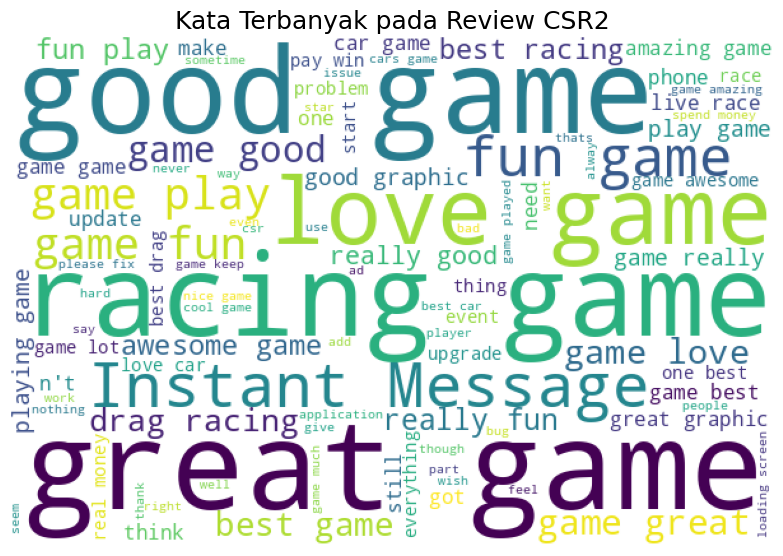

In [ ]:
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words_all)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Kata Terbanyak pada Review CSR2', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

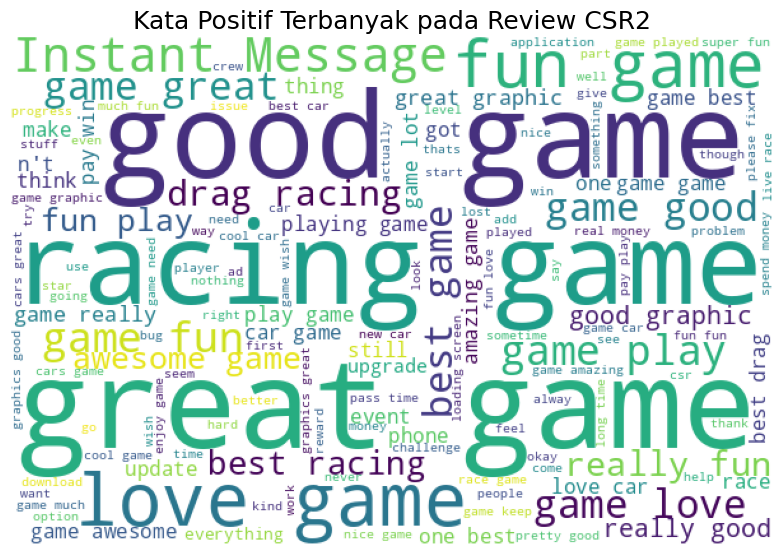

In [ ]:
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words_positive)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Kata Positif Terbanyak pada Review CSR2', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

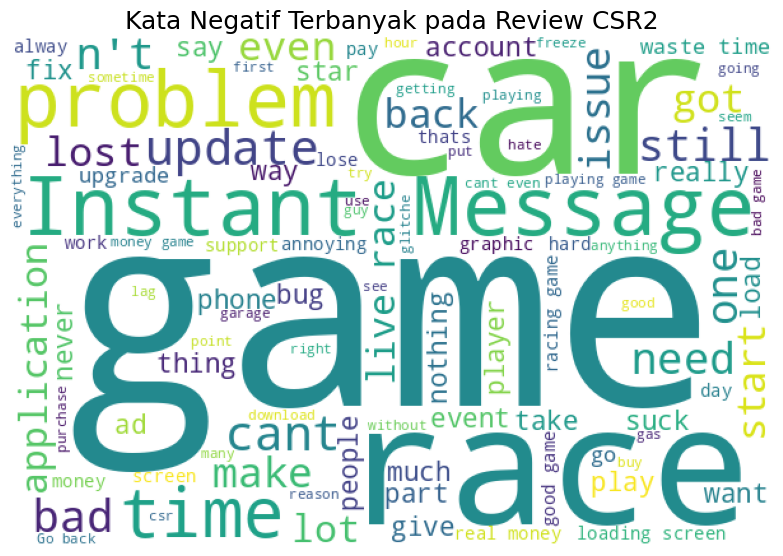

In [ ]:
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words_negative)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Kata Negatif Terbanyak pada Review CSR2', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

# **Modelling**

In [17]:
X = clean_df['text_akhir']
y = clean_df['polarity']

TF-IDF

In [18]:
tfidf = TfidfVectorizer(max_features=1000, min_df=17, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Skema pelatihan yang dicoba:
1. Logistic Regression, TF-IDF, Pembagian 80/20 (ML)
2. Dense NN, TF-IDF, Pembagian 70/30 (DL)
3. GRU, Word2Vec, 80/20 (DL)
4. LSTM, Word2Vec, 80/20 (DL)

# 1. Logistic Regression - TF-IDF - 80/20

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, stratify=y)
print(X_train.shape, X_test.shape)

(101531, 1000) (25383, 1000)


In [20]:
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train.toarray(), y_train)

y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.9676945957392323
Logistic Regression - accuracy_test: 0.9611157073631958


# 2. Dense NN - TF-IDF - Pembagian 70/30

In [21]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf.toarray(), y_encoded, test_size=0.3, stratify=y_encoded)
print(X_train.shape, X_test.shape)

(88839, 1000) (38075, 1000)


In [22]:
model_dnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_dnn.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.975):
      self.model.stop_training = True
callbacks = myCallback()

In [24]:
hist_dnn = model_dnn.fit(X_train, y_train, epochs=100, batch_size=64, callbacks = [callbacks])

Epoch 1/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8780 - loss: 0.3824
Epoch 2/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9511 - loss: 0.1431
Epoch 3/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9603 - loss: 0.1227
Epoch 4/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9652 - loss: 0.1114
Epoch 5/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9674 - loss: 0.1053
Epoch 6/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9702 - loss: 0.0990
Epoch 7/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9712 - loss: 0.0939
Epoch 8/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9720 - loss: 0.0900
Epoch 9/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9742 - loss: 0.0851
Epoch 10/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9747 - loss: 0.0837
Epoch 11/100
1389/1389 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9758 - loss: 0.0805
Epoch 12/100
1389/1

In [25]:
dnn_test_loss, dnn_test_accuracy = model_dnn.evaluate(X_test, y_test, batch_size=1)
accuracy_test_dnn = dnn_test_accuracy

38075/38075 ━━━━━━━━━━━━━━━━━━━━ 84s 2ms/step - accuracy: 0.9634 - loss: 0.1213


In [26]:
accuracy_train_dnn = hist_dnn.history['accuracy'][-1]
accuracy_test_dnn = dnn_test_accuracy

# 3. GRU - Word2Vec - 80/20

In [27]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)

# Padding input kalimat
max = 250
X_padded = pad_sequences(X_seq, maxlen=max, padding='post')

X_train, X_test, y_train, y_test = train_test_split(X_padded, y_encoded, test_size=0.3, stratify=y_encoded)
print(X_train.shape, X_test.shape)

(88839, 250) (38075, 250)


Word2Vec

In [28]:
sentences = [text.split() for text in X]
model_w2v = Word2Vec(sentences, vector_size=250, window=5, min_count=3, workers=4)

vocab_size = min(20000, len(tokenizer.word_index) + 1)
embedding_dim = 250
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
  if i < vocab_size and word in model_w2v.wv:
    embedding_matrix[i] = model_w2v.wv[word]

In [29]:
model_gru = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              input_length=max),
    GRU(64, dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.92):
      self.model.stop_training = True
callbacks = myCallback()

In [31]:
hist_gru = model_gru.fit(X_train, y_train, epochs=25, batch_size=128, callbacks = [callbacks])

Epoch 1/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8638 - loss: 0.5102
Epoch 2/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8713 - loss: 0.4815
Epoch 3/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8696 - loss: 0.4815
Epoch 4/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8696 - loss: 0.4792
Epoch 5/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8699 - loss: 0.4762
Epoch 6/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8722 - loss: 0.4692
Epoch 7/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8713 - loss: 0.4698
Epoch 8/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8696 - loss: 0.4740
Epoch 9/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8718 - loss: 0.4680
Epoch 10/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8696 - loss: 0.4727
Epoch 11/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8686 - loss: 0.4748
Epoch 12/25
695/695 ━━━━━━━━━━

In [32]:
gru_test_loss, gru_test_accuracy = model_gru.evaluate(X_test, y_test, batch_size=64)
accuracy_test_gru = gru_test_accuracy

595/595 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8687 - loss: 0.4745


In [33]:
accuracy_train_gru = hist_gru.history['accuracy'][-1]
accuracy_test_gru = gru_test_accuracy

#4. LSTM - Word2Vec - 80/20

In [34]:
# Menggunakan setup hampir sama dengan GRU
model_lstm = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              input_length=max),
    LSTM(64, dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [35]:
hist_lstm = model_lstm.fit(X_train, y_train, epochs=25, batch_size=128, callbacks = [callbacks])

Epoch 1/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8612 - loss: 0.5220
Epoch 2/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8705 - loss: 0.4841
Epoch 3/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.8712 - loss: 0.4779
Epoch 4/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8714 - loss: 0.4745
Epoch 5/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8722 - loss: 0.4697
Epoch 6/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8702 - loss: 0.4734
Epoch 7/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8708 - loss: 0.4705
Epoch 8/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8706 - loss: 0.4700
Epoch 9/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8698 - loss: 0.4715
Epoch 10/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8718 - loss: 0.4662
Epoch 11/25
695/695 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8720 - loss: 0.4664
Epoch 12/25
695/695 ━━━━━━━━━━

In [36]:
lstm_test_loss, lstm_test_accuracy = model_lstm.evaluate(X_test, y_test, batch_size=64)
accuracy_test_lstm = lstm_test_accuracy

595/595 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8687 - loss: 0.4745


In [37]:
accuracy_train_lstm = hist_lstm.history['accuracy'][-1]
accuracy_test_lstm = lstm_test_accuracy

# **Hasil Akurasi Model**

In [38]:
# DataFrame hasil akurasi
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Dense Neural Network', 'Gated Reccurent Unit', 'Long Short Term Memory'],
    'Accuracy Train': [accuracy_train_lr, accuracy_train_dnn, accuracy_train_gru, accuracy_train_lstm],
    'Accuracy Test': [accuracy_test_lr, accuracy_test_dnn, accuracy_test_gru, accuracy_test_lstm]
})

print(results_df)
# Sepertinya kedua model RNN mengalami overfitting karena akurasinya sama persis
# dengan jumlah persentase review positif (lihat: pie chart). Model RNN mungkin
# mengabaikan kedua kelas lainnya (negatif dan netral) untuk mendapatkan akurasi terbaik.

# Metode tes lain mungkin perlu dilakukan untuk mengecek performa model lebih baik.

                    Model  Accuracy Train  Accuracy Test
0     Logistic Regression        0.967695       0.961116
1    Dense Neural Network        0.975765       0.964071
2    Gated Reccurent Unit        0.870530       0.870545
3  Long Short Term Memory        0.870530       0.870545


In [39]:
accuracy_test_sorted = results_df.sort_values(by='Accuracy Test', ascending=False)
print(accuracy_test_sorted)
# Note: Pada model GRU, training memakan waktu yang lama dan tidak menunjukkan peningkatan
# akurasi yang signifikan. Oleh karena itu, epoch di-limit sebanyak 25 agar menghemat waktu

                    Model  Accuracy Train  Accuracy Test
1    Dense Neural Network        0.975765       0.964071
0     Logistic Regression        0.967695       0.961116
2    Gated Reccurent Unit        0.870530       0.870545
3  Long Short Term Memory        0.870530       0.870545


# **Inference/Testing model**

Model terbaik yang digunakan: DNN

In [40]:
def Prediksi_Sentimen(kalimat):
  # Preprocessing
  kalimat_baru_cleaned = (kalimat)
  kalimat_baru_casefolded = CaseFolding(kalimat_baru_cleaned)
  kalimat_baru_slangfixed = FixSlangwords(kalimat_baru_casefolded)
  kalimat_baru_tokenized = TokenizeText(kalimat_baru_slangfixed)
  kalimat_baru_filtered = RemoveStopwords(kalimat_baru_tokenized)
  kalimat_baru_final = ToSentence(kalimat_baru_filtered)

  X_kalimat_baru = tfidf.transform([kalimat_baru_final]).toarray()

  # Predict label kalimat
  prediksi_sentimen = model_dnn.predict(X_kalimat_baru)

  hasil_prediksi = np.argmax(prediksi_sentimen, axis=1)
  label_prediksi = encoder.inverse_transform(hasil_prediksi)

  print("Sentimen kalimat baru adalah", label_prediksi[0])

In [41]:
kalimat_baru = input("Masukkan kalimat baru: ")
Prediksi_Sentimen(kalimat_baru)

Masukkan kalimat baru: great game, interesting gameplay
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
Sentimen kalimat baru adalah positive


# **Export Model Terbaik**

In [42]:
import joblib
joblib.dump(tfidf, 'tfidf.h5')
joblib.dump(model_dnn, 'model_dnn.h5')

['model_dnn.h5']

In [43]:
!pip freeze > requirements.txt